In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("08-2024.csv")

In [5]:
df.head()

,Record ID,Activity date,Call direction,Call duration,hs_call_outcome,Activity assigned to
0,57444894807,2024-08-01 09:02,NaN,01:17:09,NaN,David Valdez
1,57438539433,2024-08-01 09:27,NaN,NaN,NaN,Robin Stoehr
2,57438828546,2024-08-01 09:29,NaN,NaN,NaN,Robin Stoehr
3,57436337409,2024-08-01 09:32,Outbound,00:00:47,NaN,Sam Steindorf
4,57435922490,2024-08-01 09:32,Outbound,00:01:06,NaN,Robin Stoehr


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7676 entries, 0 to 7675
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Record ID             7676 non-null   int64  
 1   Activity date         7676 non-null   str    
 2   Call direction        5598 non-null   str    
 3   Call duration         6102 non-null   str    
 4   hs_call_outcome       0 non-null      float64
 5   Activity assigned to  7483 non-null   str    
dtypes: float64(1), int64(1), str(4)
memory usage: 663.5 KB


In [9]:
df1 = df.drop(columns=['hs_call_outcome', 'Record ID'])

In [11]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 7676 entries, 0 to 7675
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Activity date         7676 non-null   str  
 1   Call direction        5598 non-null   str  
 2   Call duration         6102 non-null   str  
 3   Activity assigned to  7483 non-null   str  
dtypes: str(4)
memory usage: 543.5 KB


In [13]:
df1['Activity date'] = pd.to_datetime(
    df1['Activity date'],
    format="%Y-%m-%d %H:%M",
    errors="coerce"
)

In [15]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 7676 entries, 0 to 7675
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         7676 non-null   datetime64[us]
 1   Call direction        5598 non-null   str           
 2   Call duration         6102 non-null   str           
 3   Activity assigned to  7483 non-null   str           
dtypes: datetime64[us](1), str(3)
memory usage: 423.6 KB


# Call Count per day

In [18]:
df2 = df1.copy()

In [20]:
df2['date'] = df2['Activity date'].dt.date

In [22]:
df2.head()

,Activity date,Call direction,Call duration,Activity assigned to,date
0,2024-08-01 09:02:00,NaN,01:17:09,David Valdez,2024-08-01
1,2024-08-01 09:27:00,NaN,NaN,Robin Stoehr,2024-08-01
2,2024-08-01 09:29:00,NaN,NaN,Robin Stoehr,2024-08-01
3,2024-08-01 09:32:00,Outbound,00:00:47,Sam Steindorf,2024-08-01
4,2024-08-01 09:32:00,Outbound,00:01:06,Robin Stoehr,2024-08-01


In [24]:
daily_calls = (
    df2.groupby(df2['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date': 'date'})
)

In [26]:
daily_calls.head()

,date,call_count
0,2024-08-01,282
1,2024-08-02,266
2,2024-08-03,104
3,2024-08-04,44
4,2024-08-05,256


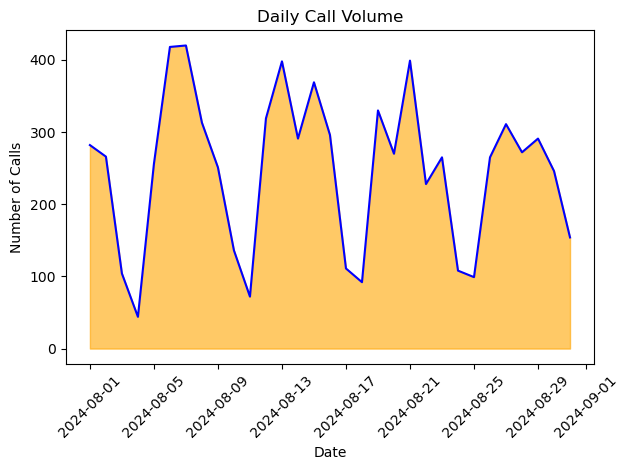

In [28]:
plt.figure()
plt.plot(daily_calls['date'], daily_calls['call_count'],color='blue')

plt.fill_between(daily_calls['date'], daily_calls['call_count'], color='orange', alpha=0.6)

plt.title("Daily Call Volume")
plt.xlabel("Date")
plt.ylabel("Number of Calls")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Count of Call in Weekdays

In [31]:
df1['day'] = df1['Activity date'].dt.day_name()

In [33]:
df1.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
0,2024-08-01 09:02:00,NaN,01:17:09,David Valdez,Thursday
1,2024-08-01 09:27:00,NaN,NaN,Robin Stoehr,Thursday
2,2024-08-01 09:29:00,NaN,NaN,Robin Stoehr,Thursday
3,2024-08-01 09:32:00,Outbound,00:00:47,Sam Steindorf,Thursday
4,2024-08-01 09:32:00,Outbound,00:01:06,Robin Stoehr,Thursday


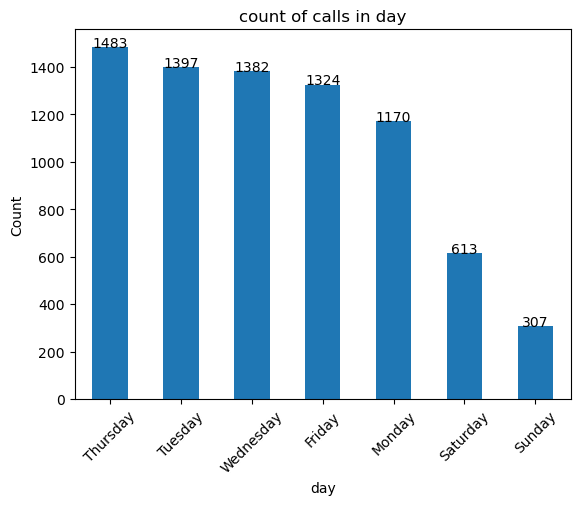

In [35]:
day_Counts = df1["day"].value_counts()
day_Counts.plot(kind='bar')
ax= day_Counts.plot(kind='bar')

for i,v in enumerate(day_Counts):
    ax.text(i, v+1, str(v), ha="center")

plt.title("count of calls in day")
plt.xlabel("day")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Inbound VS Outbound

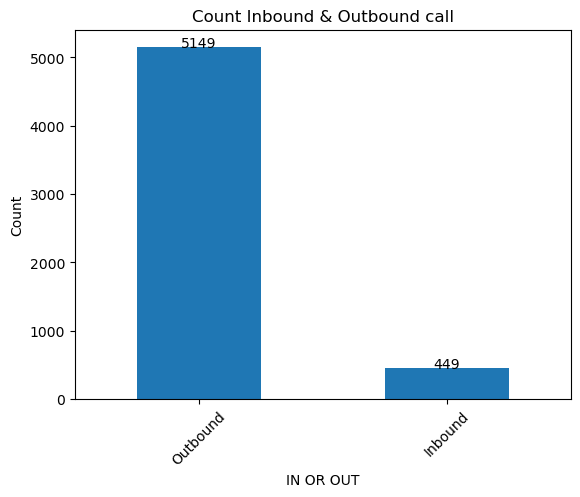

In [40]:
IN_OUT_COUNT = df1['Call direction'].value_counts()
IN_OUT_COUNT.plot(kind='bar')
ax = IN_OUT_COUNT.plot(kind='bar')

for i,v in enumerate(IN_OUT_COUNT):
    ax.text(i, v+1, str(v), ha="center")

plt.title("Count Inbound & Outbound call")
plt.xlabel("IN OR OUT")
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Count 00 Duration for Bound

In [43]:
N_B = df1[(df1['Call duration'] == "00:00:00")]

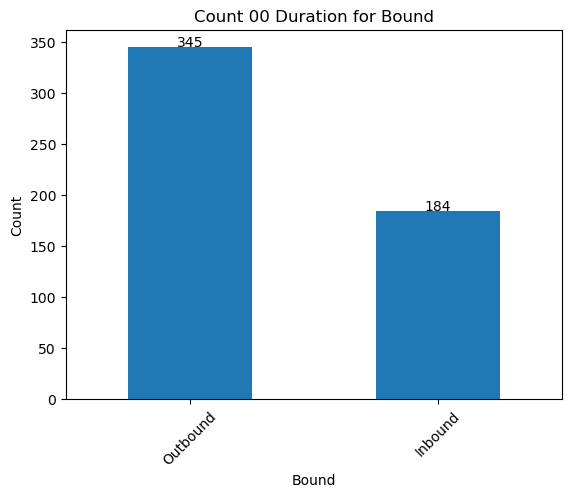

In [45]:
N_B_Counts = N_B['Call direction'].value_counts()
N_B_Counts.plot(kind="bar")
ax = N_B_Counts.plot(kind="bar")

for i,v in enumerate(N_B_Counts):
    ax.text(i, v+1, str(v), ha="center")

plt.title("Count 00 Duration for Bound")
plt.xlabel("Bound")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Call duration NULL but have Call direction

In [48]:
df1[(df1['Call duration'].isnull()) & (df1['Call direction'].notnull())]

,Activity date,Call direction,Call duration,Activity assigned to,day
155,2024-08-01 16:06:00,Outbound,NaN,Sam Steindorf,Thursday
1108,2024-08-06 14:00:00,Outbound,NaN,Chrystel Manabat,Tuesday
1329,2024-08-06 20:06:00,Outbound,NaN,Sam Steindorf,Tuesday
1765,2024-08-07 21:30:00,Outbound,NaN,Sam Steindorf,Wednesday
2556,2024-08-11 18:50:00,Outbound,NaN,Sam Steindorf,Sunday
3244,2024-08-13 19:45:00,Outbound,NaN,Sam Steindorf,Tuesday
3544,2024-08-14 18:41:00,Outbound,NaN,David Valdez,Wednesday
6181,2024-08-26 11:17:00,Outbound,NaN,Juan Calo,Monday
6414,2024-08-27 10:55:00,Inbound,NaN,Sam Steindorf,Tuesday


In [50]:
df4 = df1.copy()

In [52]:
df4['Call duration'] = (
    pd.to_timedelta(df4['Call duration'], errors = 'coerce')
    .dt.total_seconds()/60
)

In [54]:
(df4['Call duration'] == 0).sum()

529

In [56]:
df4.info()

<class 'pandas.DataFrame'>
RangeIndex: 7676 entries, 0 to 7675
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         7676 non-null   datetime64[us]
 1   Call direction        5598 non-null   str           
 2   Call duration         6102 non-null   float64       
 3   Activity assigned to  7483 non-null   str           
 4   day                   7676 non-null   str           
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 489.4 KB


In [58]:
df4['Call duration'] = df4['Call duration'].fillna(0)

In [60]:
df4 = df4.dropna(subset = ['Call direction'])

In [62]:
(df4['Call duration'] == 0).sum()

538

In [64]:
df4.info()

<class 'pandas.DataFrame'>
Index: 5598 entries, 3 to 7675
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         5598 non-null   datetime64[us]
 1   Call direction        5598 non-null   str           
 2   Call duration         5598 non-null   float64       
 3   Activity assigned to  5415 non-null   str           
 4   day                   5598 non-null   str           
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 411.6 KB


# Working Call Assigner

In [67]:
df1['Activity assigned to'].nunique()

20

In [69]:
df1['Activity assigned to'].unique()

<ArrowStringArray>
[     'David Valdez',      'Robin Stoehr',     'Sam Steindorf',
    'Cameron Dudley',     'Keith Antonio',         'Juan Calo',
     'Oliver Martin',                 nan,    'Boston Hoppman',
        'Tyler Jury',     'Garrett Evans',        'Henry Good',
      'Bill Goodwin',       'Paol Guzman',    'David Banister',
      'Karen Parker',         'Terry Kim',  'Chrystel Manabat',
   'Adonis Baybayan', 'Brittany Digiulio',      'Stephen Tarr']
Length: 21, dtype: str

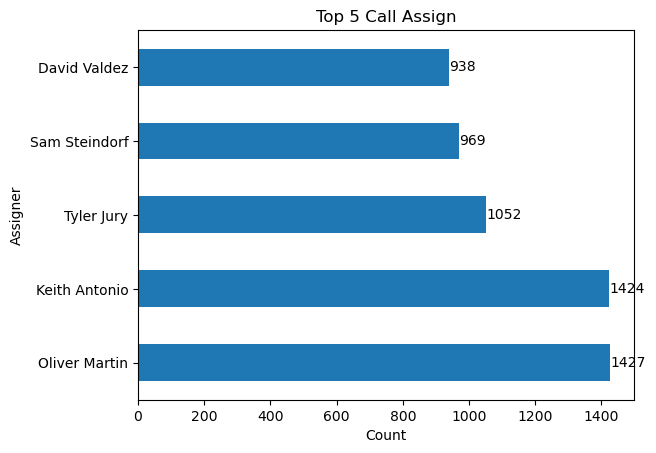

In [71]:
ASSI_COUNT = df1['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# Max Call Duration

In [74]:
df4['Call duration'].max()

74.15

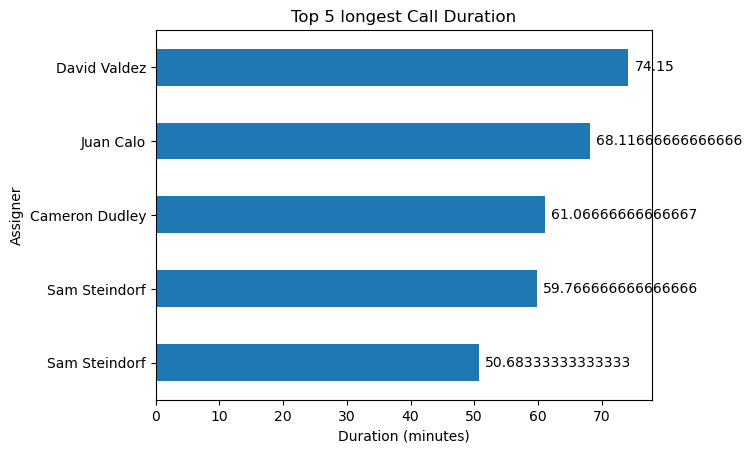

In [76]:
top5 = df4.nlargest(5, "Call duration")

ax = top5.set_index('Activity assigned to')['Call duration'].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

# Only Weekdays Call Volume

In [79]:
df3 = df1.copy()

In [81]:
df3 = df3[~df3['day'].isin(['Saturday', 'Sunday'])]

In [83]:
df3['day'].unique()

<ArrowStringArray>
['Thursday', 'Friday', 'Monday', 'Tuesday', 'Wednesday']
Length: 5, dtype: str

In [85]:
week_day_calls=(
    df3.groupby(df3['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date': 'date'})
)

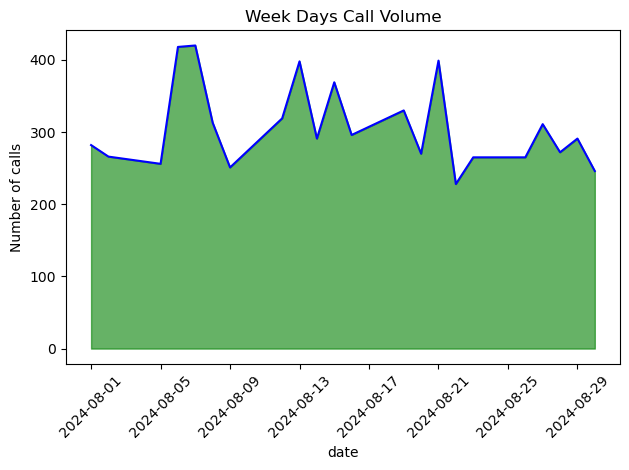

In [87]:
plt.figure()
plt.plot(week_day_calls['date'], week_day_calls['call_count'], color='blue')

plt.fill_between(week_day_calls['date'], week_day_calls['call_count'],color='green', alpha=0.6)

plt.title("Week Days Call Volume")
plt.xlabel("date")
plt.ylabel("Number of calls")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# WEEKEND TIME DURATION

In [90]:
df5=df4.copy()

In [92]:
df5 = df5[~df5['day'].isin(['Monday', 'Thursday', 'Friday', 'Wednesday', 'Tuesday'])]

In [94]:
df5.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
548,2024-08-03 08:06:00,Outbound,3.233333,Sam Steindorf,Saturday
549,2024-08-03 08:15:00,Outbound,0.316667,Sam Steindorf,Saturday
550,2024-08-03 08:15:00,Outbound,0.216667,Sam Steindorf,Saturday
551,2024-08-03 08:42:00,Outbound,0.350000,Sam Steindorf,Saturday
552,2024-08-03 08:43:00,Outbound,0.133333,Sam Steindorf,Saturday


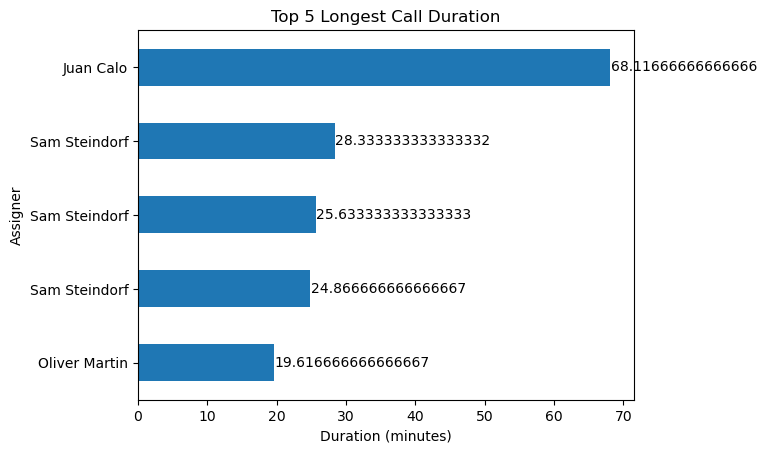

In [96]:
top5 = df5.nlargest(5, "Call duration")

ax = top5.set_index("Activity assigned to")["Call duration"].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v + 0.1, i, str(v), va="center")

plt.title("Top 5 Longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

# Top 5 Weekend Call Assigner

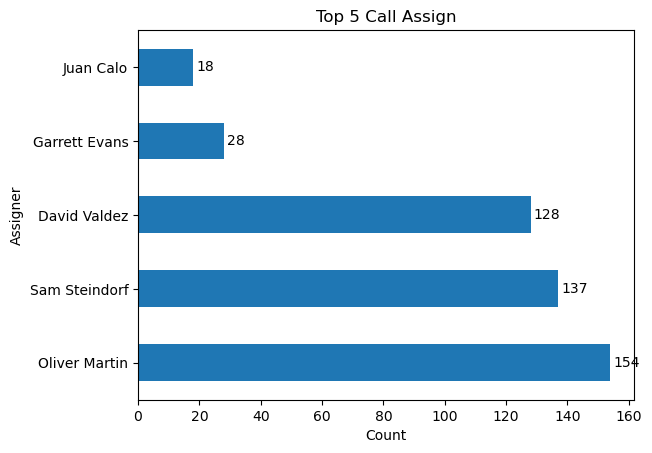

In [99]:
ASSI_COUNT = df5['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# Without Call Assigner Calls

In [102]:
df6 = df3.copy()

In [104]:
df6['month'] = df6['Activity date'].dt.month_name()

In [106]:
no_assigner_calls = df6[df6["Activity assigned to"].isna()]

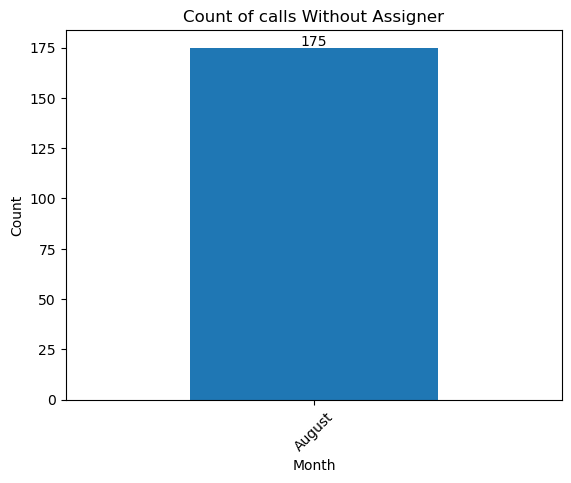

In [108]:
month_counts = no_assigner_calls["month"].value_counts()
month_counts.plot(kind="bar")
ax = month_counts.plot(kind="bar")

for i, v in enumerate(month_counts):
    ax.text(i, v + 1, str(v), ha="center")

plt.title("Count of calls Without Assigner")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Top 5 Peak Call Date

In [111]:
daily_calls = df.groupby(df2["Activity date"].dt.date).size()

In [113]:
top5 = daily_calls.sort_values(ascending=False).head(5)

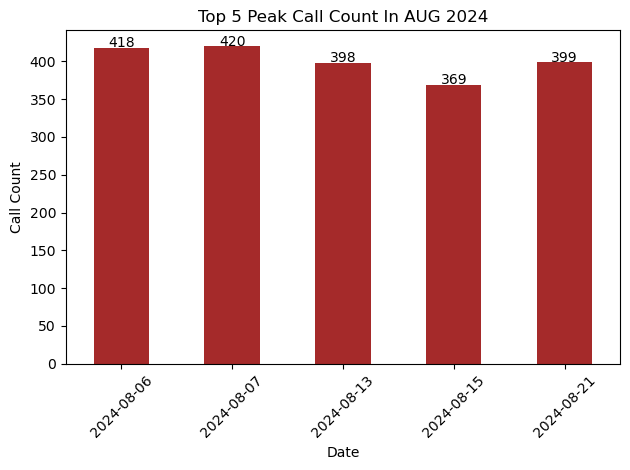

In [117]:
ax = top5.sort_index().plot(kind="bar", color="brown")

for i, v in enumerate(top5.sort_index()):
    ax.text(i, v + 0.5, str(v), ha="center", fontsize=10)
    
plt.title("Top 5 Peak Call Count In AUG 2024")
plt.xlabel("Date")
plt.ylabel("Call Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()